In [22]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [23]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

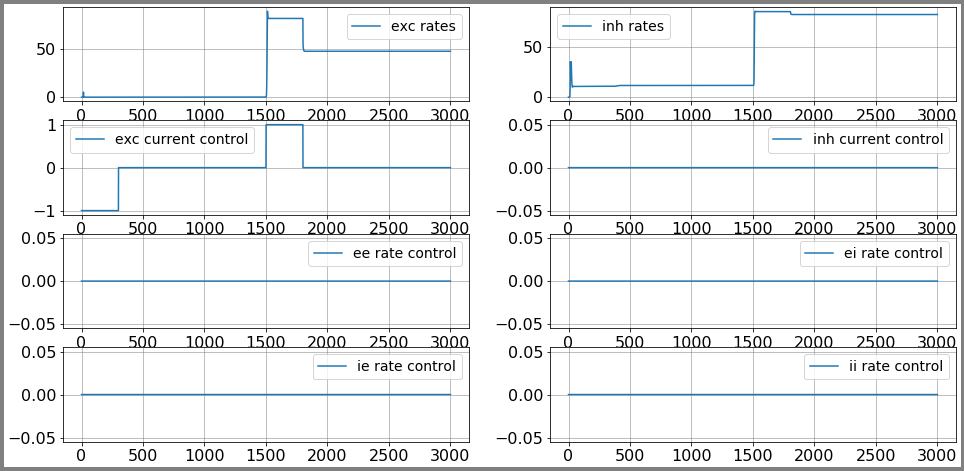

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


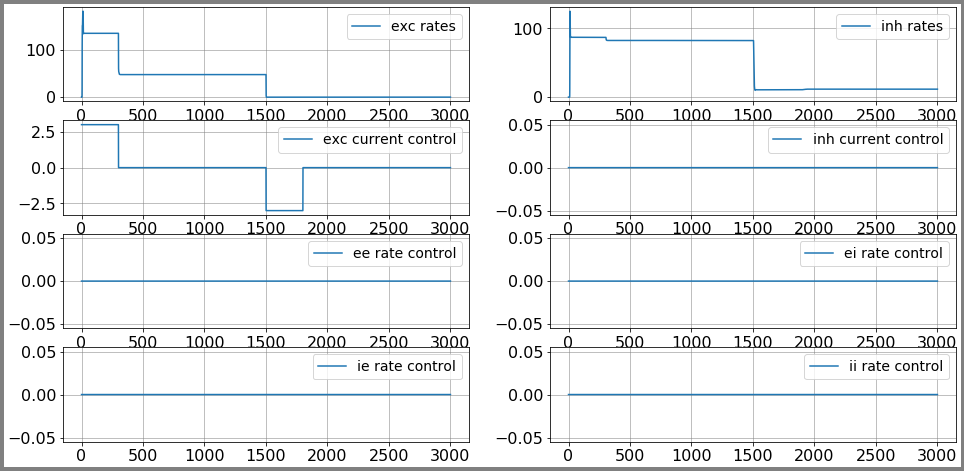

In [24]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]


In [25]:
# 8 cases
# ee, ei, ie, ii
c_var = [ [0], [1], [0,1], [2], [3], [4], [5], [2,3,4,5] ]
p_var = [ [0], [0], [0], [0], [0], [0], [0], [0] ]

bestControla = [ [], [], [], [], [], [], [], [] ]
bestStatea = [ [], [], [], [], [], [], [], [] ]
costa = [ [], [], [], [], [], [], [], [] ]
runtimea = [ [], [], [], [], [], [], [], [] ]
grada = [ [], [], [], [], [], [], [], [] ]
phia= [ [], [], [], [], [], [], [], [] ]

bestControlb = [ [], [], [], [], [], [], [], [] ]
bestStateb = [ [], [], [], [], [], [], [], [] ]
costb = [ [], [], [], [], [], [], [], [] ]
runtimeb = [ [], [], [], [], [], [], [], [] ]
gradb = [ [], [], [], [], [], [], [], [] ]
phib= [ [], [], [], [], [], [], [], [] ]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])
initVars = low_state_vars

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

sheet = "state_switching"
max_it = 1000

### Cases

Numer | Input | Input label | Result
---------|--------------|-----------|-----------
1 | E current | 0 | 0
2 | I current | 1 | 0
3 | E + I current | 0,1 | 0
4 | EE rate | 2 | 0
5 | EI rate | 3 | 0
6 | IE rate | 4 | 0
7 | II rate | 5 | 0
8 | EE + EI + IE + II rate | 2,3,4,5 | 0

## 1

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1778.9203660693015
RUN  3 , total integrated cost =  89.15108951247882
RUN  4 , total integrated cost =  21.38238446628905
RUN  5 , total integrated cost =  9.302117816895592
RUN  6 , total integrated cost =  5.400643216093798
RUN  7 , total integrated cost =  3.6216180163576244
RUN  8 , total integrated cost =  2.5974319033783986
RUN  9 , total integrated cost =  1.9441276854019511
RUN  10 , total integrated cost =  1.5263339942531167
RUN  11 , total integrated cost =  1.2425486610332994
RUN  12 , total integrated cost =  1.0310405867183763
RUN  13 , total integrated cost =  0.8636988660672524
RUN  14 , total integrated cost =  0.735332655717568
RUN  15 , total integrated cost =  0.639349041016721
RUN  16 , total integr

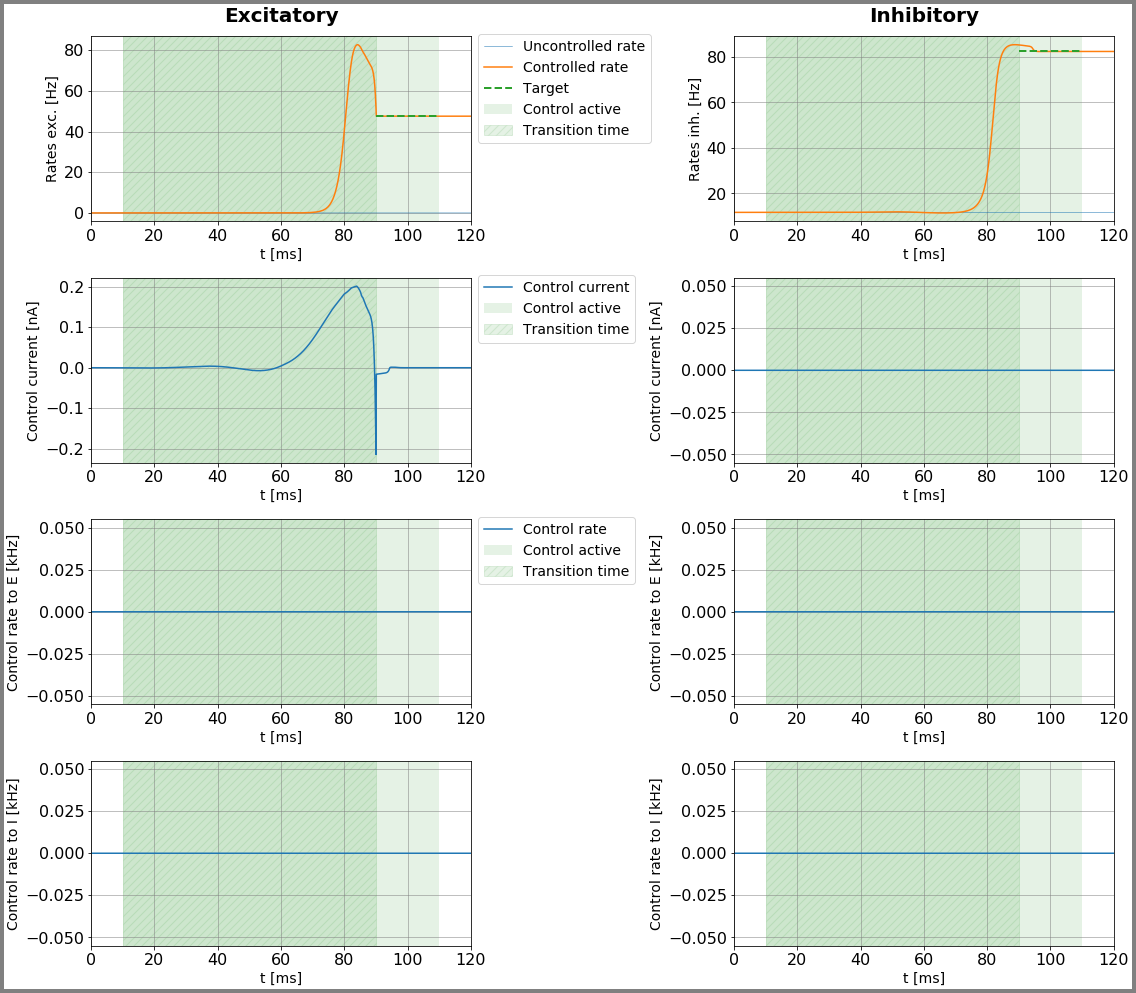

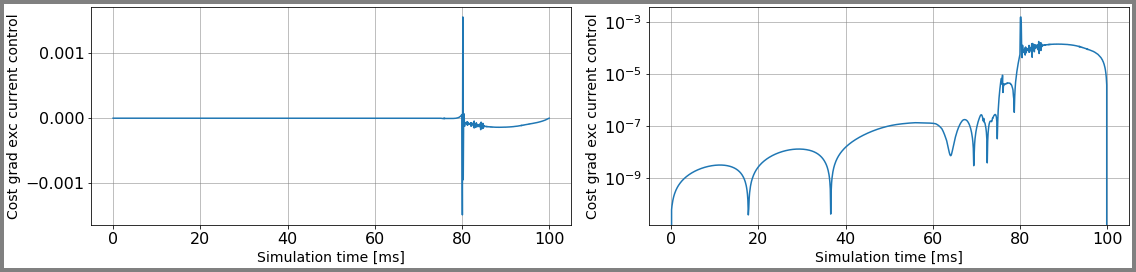

In [26]:
c_ = 0
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(control0,
    target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  3576.0205325579936
RUN  2 , total integrated cost =  2223.7360395363344
RUN  3 , total integrated cost =  1492.953941661432
RUN  4 , total integrated cost =  1110.440522649508
RUN  5 , total integrated cost =  771.1737007871285
RUN  6 , total integrated cost =  624.0269599066786
RUN  7 , total integrated cost =  536.5192911950995
RUN  8 , total integrated cost =  480.93944826538365
RUN  9 , total integrated cost =  439.65639744304417
RUN  10 , total integrated cost =  412.39475807306945
RUN  11 , total integrated cost =  388.2180678806318
RUN  12 , total integrated cost =  370.71530367476436
RUN  13 , total integrated cost =  357.0470359076686
RUN  14 , total integrated cost =  345.77539702889084
RUN  15 , total integrated cost =  336.6865105782246
RUN  16 , total integra

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  102.18155693670033
RUN  1000 , total integrated cost =  102.18155693670033
Improved over  1000  iterations in  53.17587849999836  seconds by  99.5457283990917  percent.
Problem in initial value trasfer:  Vmean_exc -56.174591299754944 -56.17459128940741


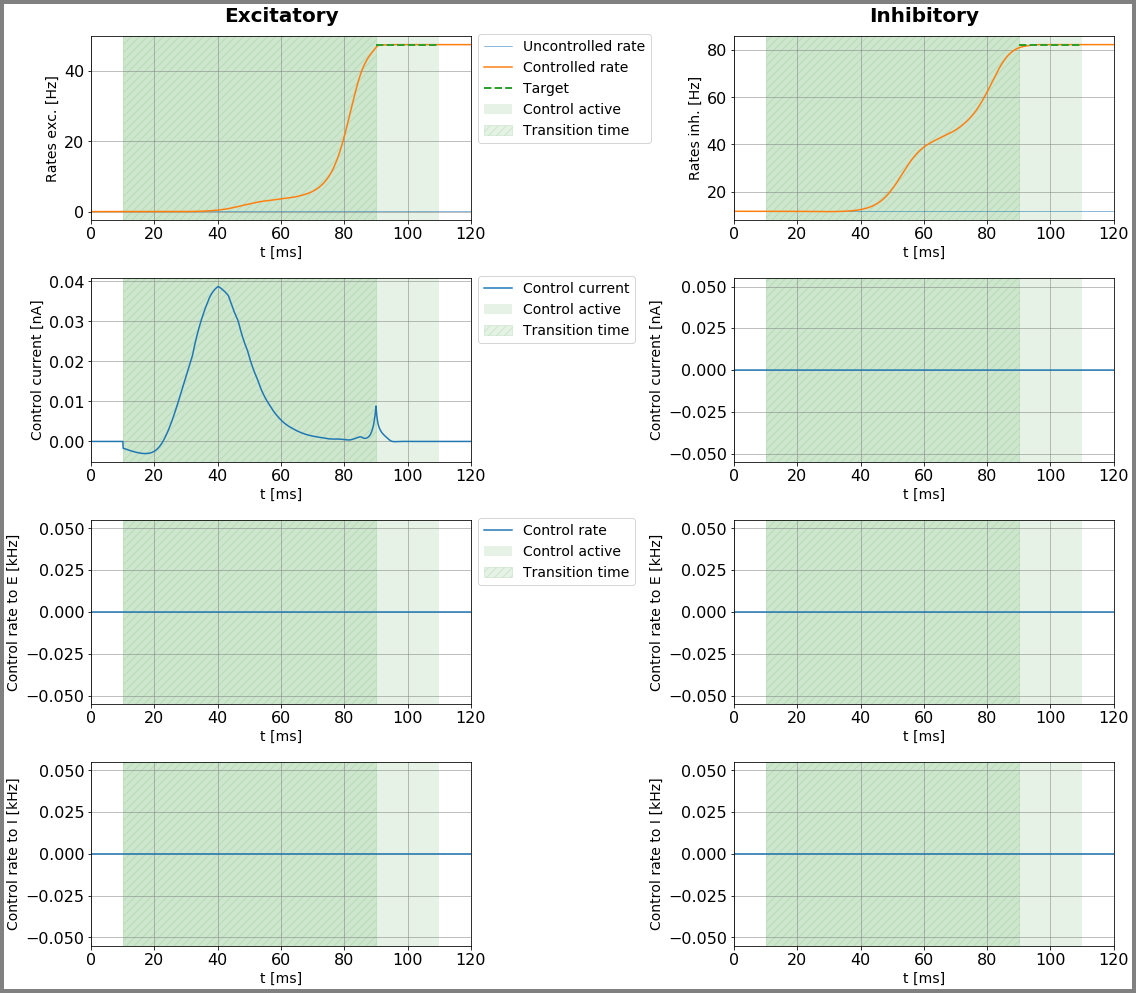

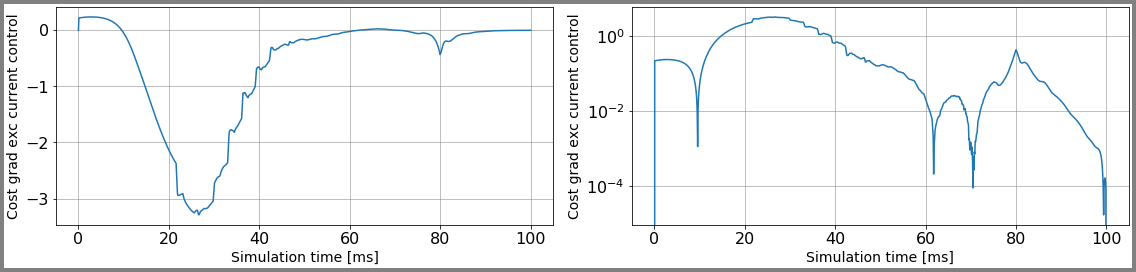

In [27]:
c_ = 0
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 2

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  3859.672296503376
RUN  2 , total integrated cost =  88.30540409162167
RUN  3 , total integrated cost =  1.2412311560575862
RUN  4 , total integrated cost =  0.0598230614877892
RUN  5 , total integrated cost =  0.029961637979352862
RUN  6 , total integrated cost =  0.002949038737146899
RUN  7 , total integrated cost =  0.0015037102635284587
RUN  8 , total integrated cost =  0.0011131193937577847
RUN  9 , total integrated cost =  0.0008873623634675265
RUN  10 , total integrated cost =  0.0007342924806327018
RUN  11 , total integrated cost =  0.0006198705246234058
RUN  12 , total integrated cost =  0.000528319977673254
RUN  13 , total integrated cost =  0.00045085164027131844
RUN  14 , total integrated cost =  0.00038826517153170214
RUN  15 , total integrated cost =  0.00033

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  8.326046583743515e-08
RUN  1000 , total integrated cost =  8.326046583743515e-08
Improved over  1000  iterations in  23.5532204  seconds by  99.99999999962985  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459399763963 -56.174597782292906


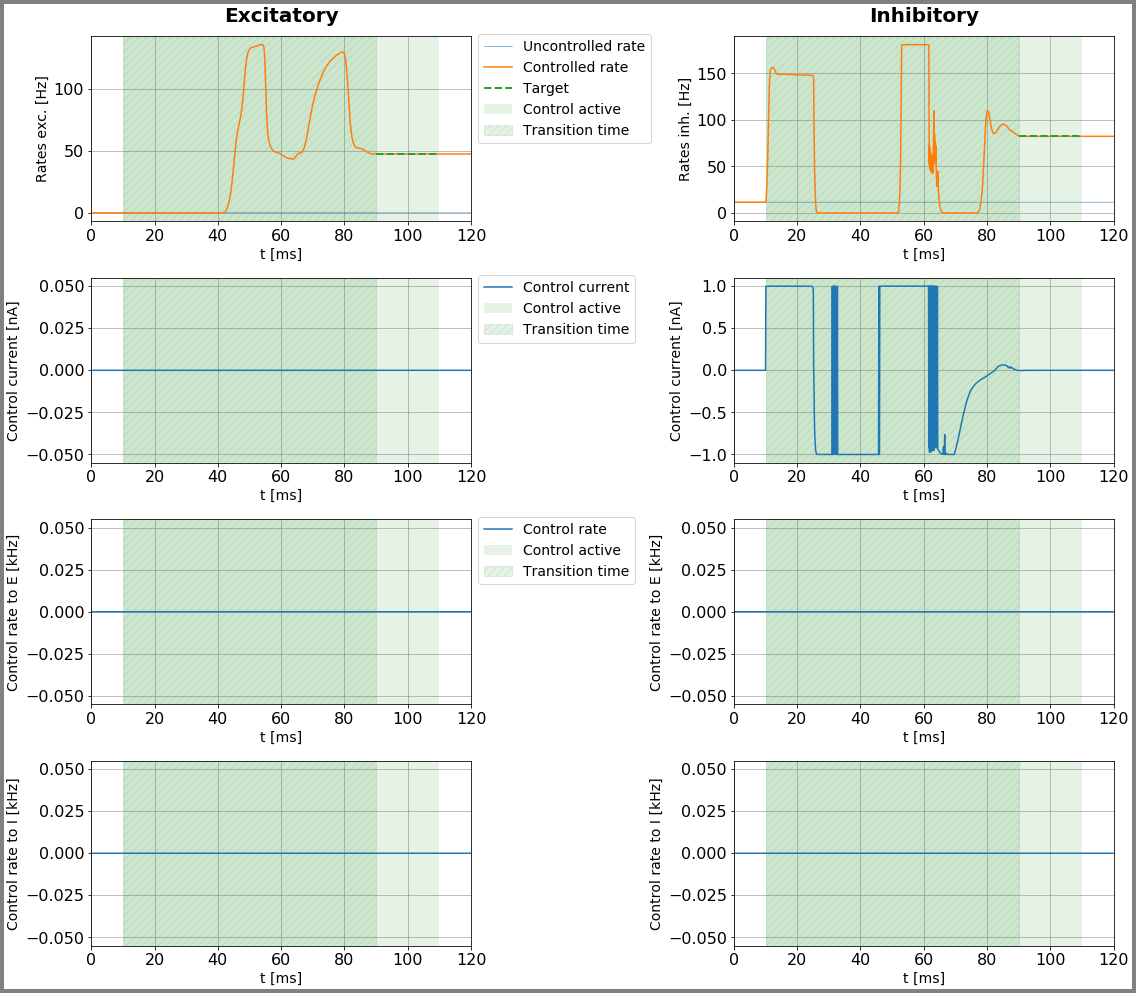

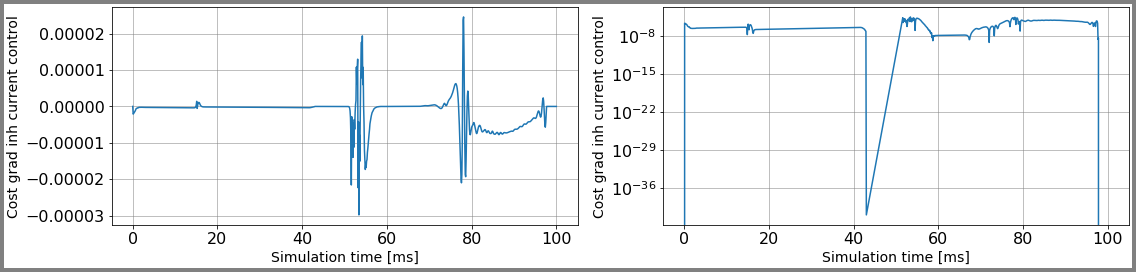

In [7]:
c_ = 1
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  4285.377245862553
RUN  2 , total integrated cost =  922.8709906618799
RUN  3 , total integrated cost =  705.4505181306145
RUN  4 , total integrated cost =  178.2030313784224
RUN  5 , total integrated cost =  163.2944358518199
RUN  6 , total integrated cost =  156.62545203708987
RUN  7 , total integrated cost =  147.63846157431647
RUN  8 , total integrated cost =  142.68715782224254
RUN  9 , total integrated cost =  136.09252045933295
RUN  10 , total integrated cost =  132.2446116823852
RUN  11 , total integrated cost =  127.12334810073688
RUN  12 , total integrated cost =  123.84215237475365
RUN  13 , total integrated cost =  119.45484842664531
RUN  14 , total integrated cost =  116.6481574817945
RUN  15 , total integrated cost =  113.03288670735415
RUN  16 , total integr

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  49.56715340042566
RUN  1000 , total integrated cost =  49.56715340042566
Improved over  1000  iterations in  23.19084869999999  seconds by  99.77963782503699  percent.
Problem in initial value trasfer:  Vmean_exc -56.174589071080845 -56.17458915610762


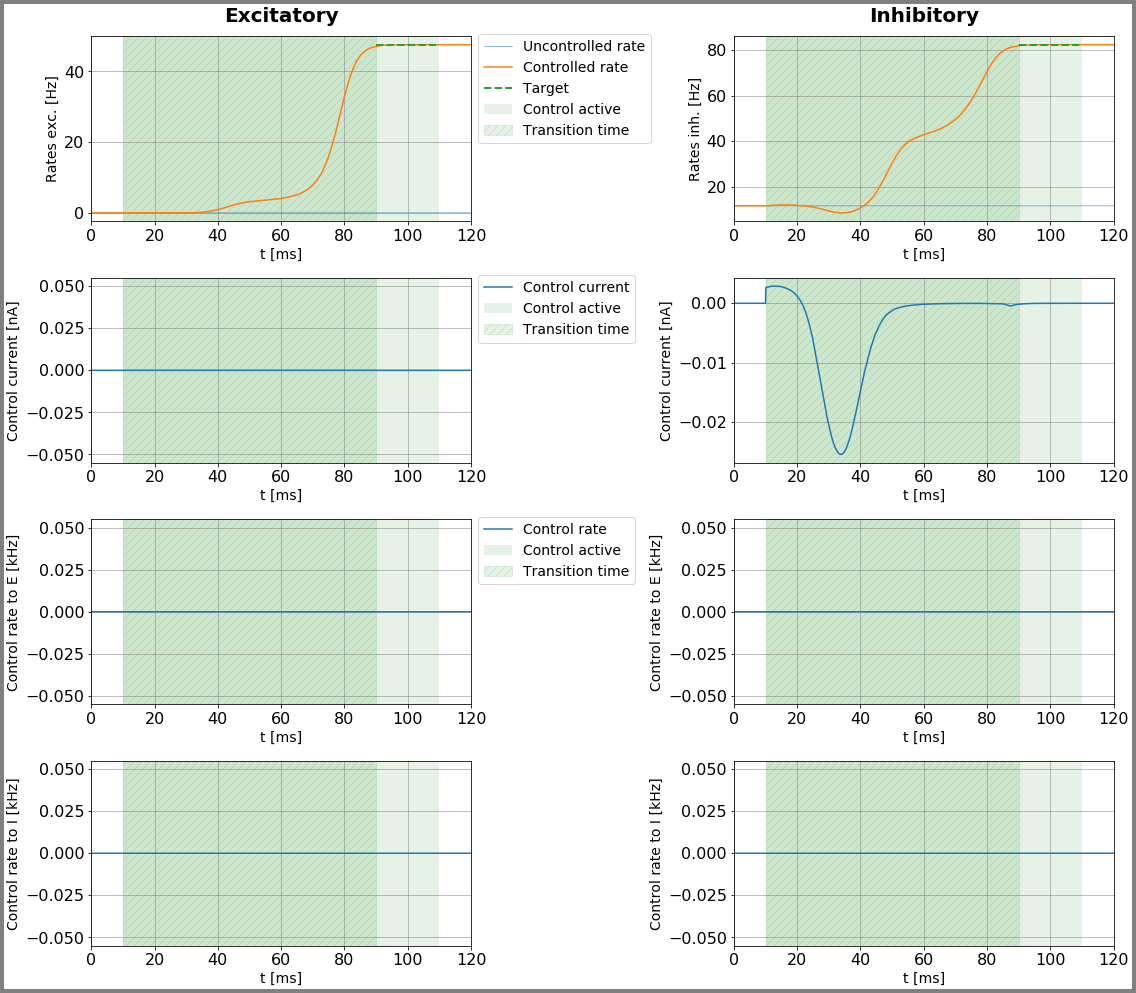

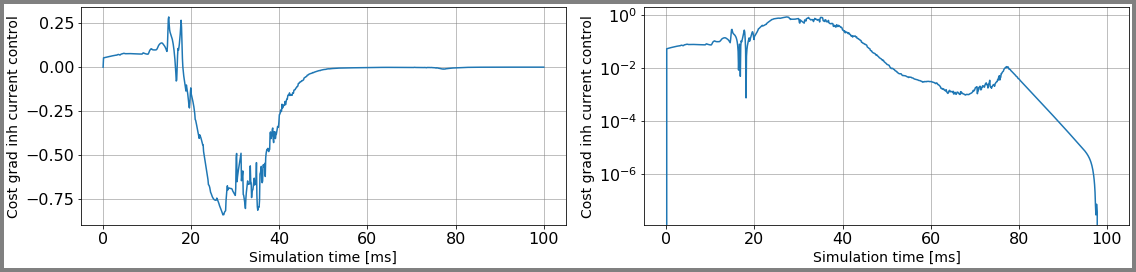

In [8]:
c_ = 1
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 3

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1727.5249571588436
RUN  3 , total integrated cost =  537.9247471416692
RUN  4 , total integrated cost =  310.94839325314246
RUN  5 , total integrated cost =  199.0846206850091
RUN  6 , total integrated cost =  132.08026047641465
RUN  7 , total integrated cost =  89.81125768788664
RUN  8 , total integrated cost =  64.6722086266404
RUN  9 , total integrated cost =  47.648911482440894
RUN  10 , total integrated cost =  36.7603536670014
RUN  11 , total integrated cost =  29.258933102448715
RUN  12 , total integrated cost =  23.906448836445445
RUN  13 , total integrated cost =  20.032118726877286
RUN  14 , total integrated cost =  17.095538808581622
RUN  15 , total integrated cost =  14.780863171054927
RUN  16 , total inte

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.00046238711798886074
RUN  1000 , total integrated cost =  0.00046238711798886074
Improved over  1000  iterations in  43.49460590000001  seconds by  99.99999794435178  percent.
Problem in initial value trasfer:  Vmean_exc -56.174590026845394 -56.174585427317744


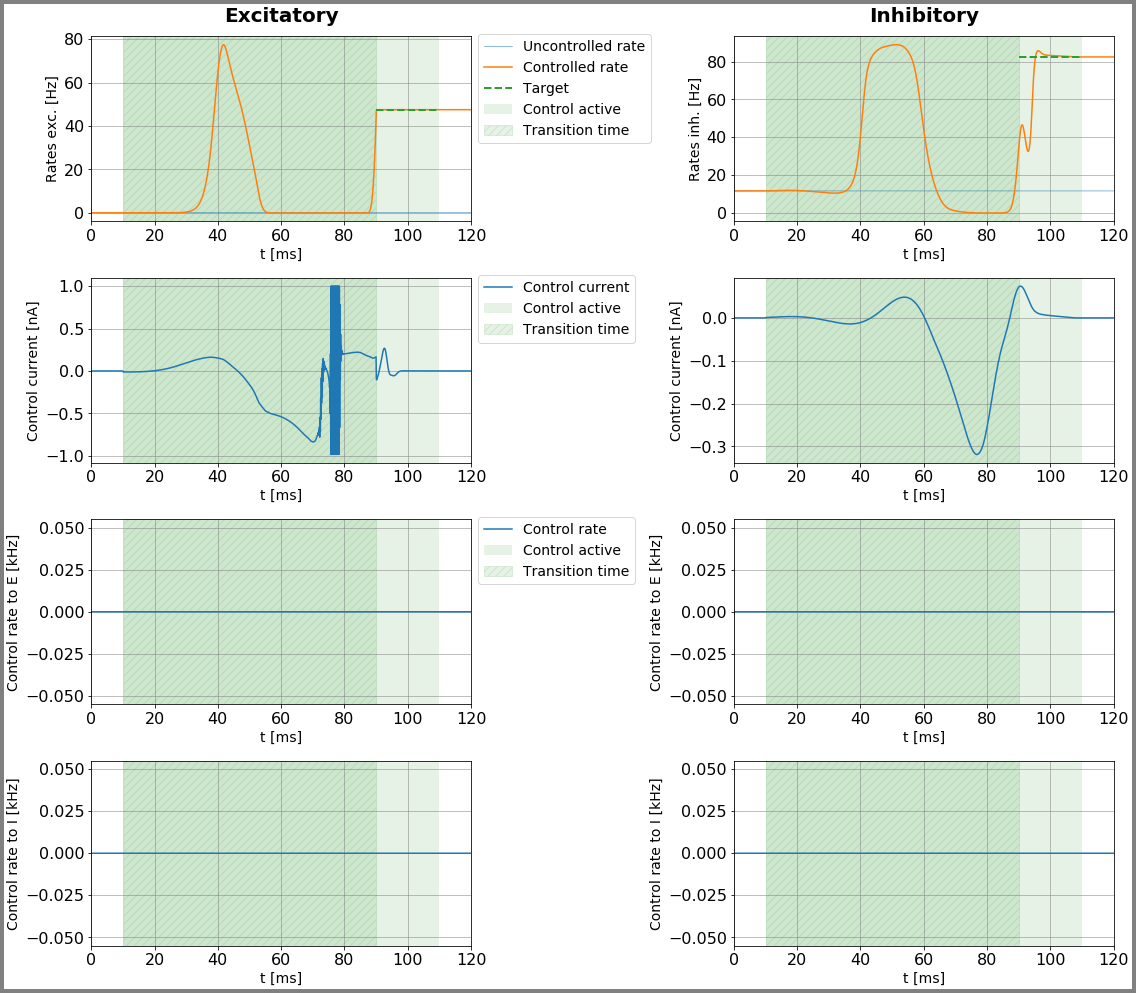

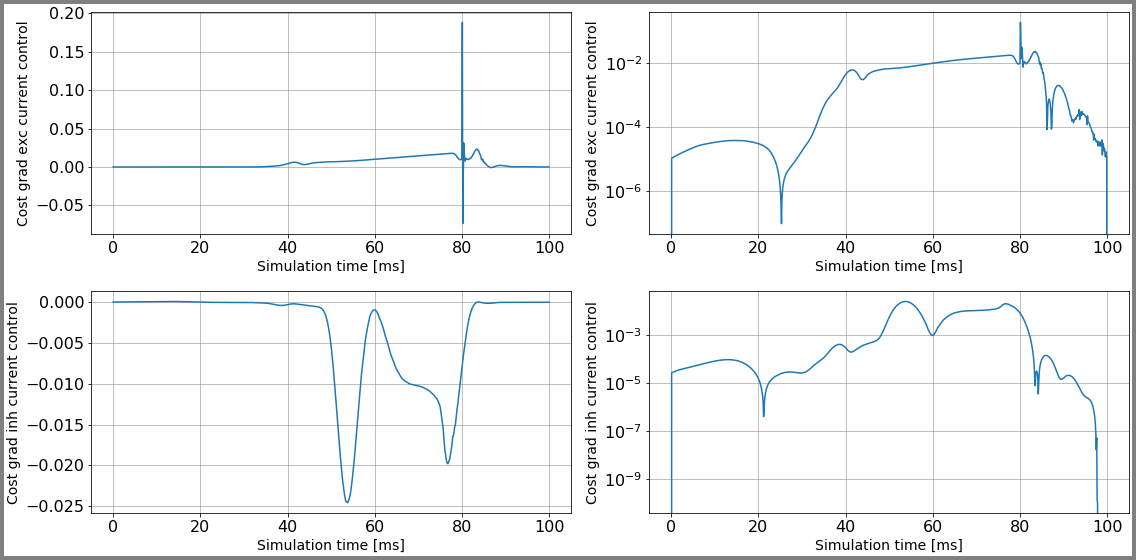

In [9]:
c_ = 2
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  3553.1012438466405
RUN  2 , total integrated cost =  1207.9275179872025
RUN  3 , total integrated cost =  461.05124403910656
RUN  4 , total integrated cost =  233.6593191189111
RUN  5 , total integrated cost =  190.88406080140473
RUN  6 , total integrated cost =  156.58871646246348
RUN  7 , total integrated cost =  138.2029829446584
RUN  8 , total integrated cost =  128.39944710308018
RUN  9 , total integrated cost =  124.67503124912784
RUN  10 , total integrated cost =  120.96134298380522
RUN  11 , total integrated cost =  118.56031693902038
RUN  12 , total integrated cost =  116.1052253935948
RUN  13 , total integrated cost =  114.38083468460135
RUN  14 , total integrated cost =  112.60955953881069
RUN  15 , total integrated cost =  111.09497784300667
RUN  16 , total

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  49.73410507097368
RUN  1000 , total integrated cost =  49.73410507097368
Improved over  1000  iterations in  73.7108953  seconds by  99.77889560300663  percent.
Problem in initial value trasfer:  Vmean_exc -56.174588825525426 -56.174588920018444


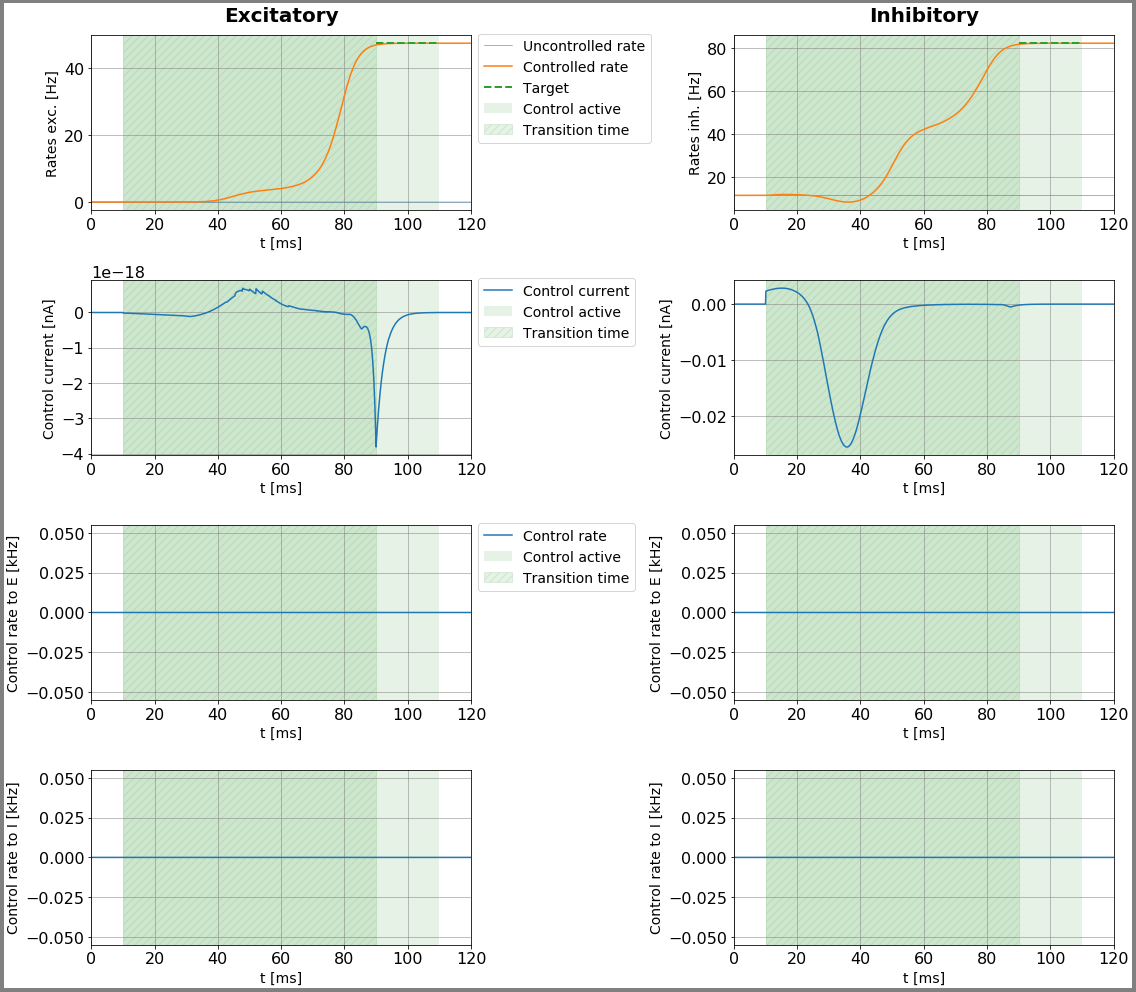

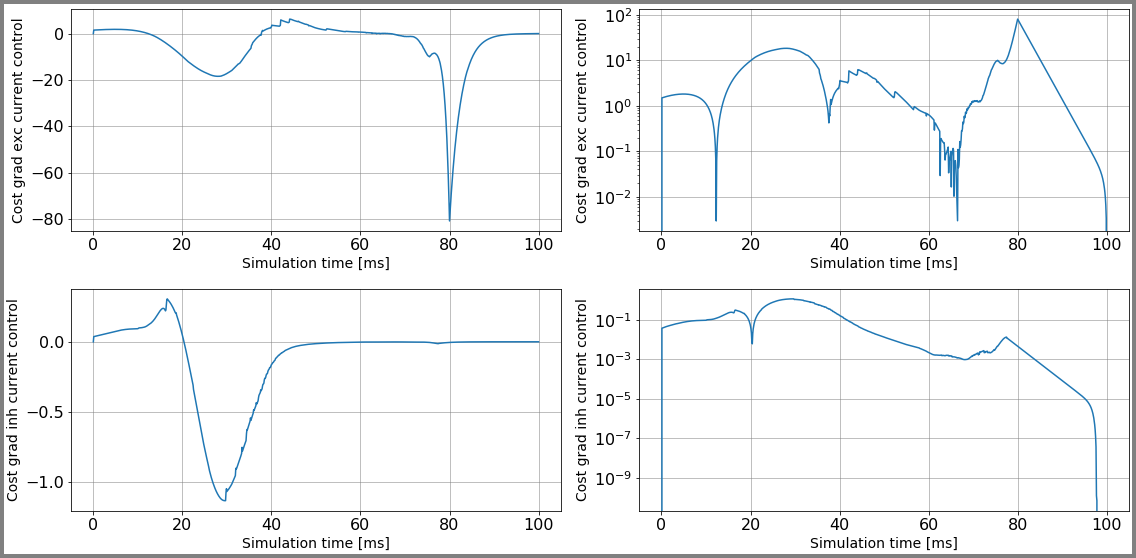

In [10]:
c_ = 2
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 4

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  103.36100728751417
Gradient descend method:  None
RUN  1 , total integrated cost =  0.013911159021427378
RUN  2 , total integrated cost =  8.040291425226108e-05
RUN  3 , total integrated cost =  5.398596422202372e-08
RUN  4 , total integrated cost =  2.0147278438461749e-10
RUN  5 , total integrated cost =  2.3989359046581984e-13
RUN  6 , total integrated cost =  1.1334372475805718e-16
RUN  7 , total integrated cost =  3.8500038433061263e-19
RUN  8 , total integrated cost =  2.95189370267035e-22
RUN  9 , total integrated cost =  1.1904504283185783e-22
RUN  10 , total integrated cost =  9.132953195395951e-23
RUN  11 , total integrated cost =  7.187604532636659e-23
RUN  12 , total integrated cost =  4.2195629608324075e-23
RUN  13 , total integrated cost =  1.1037994221342037e-25
RUN  14 , total integrated cost =  1.3303350305647134e-26
RUN  15 , total integ

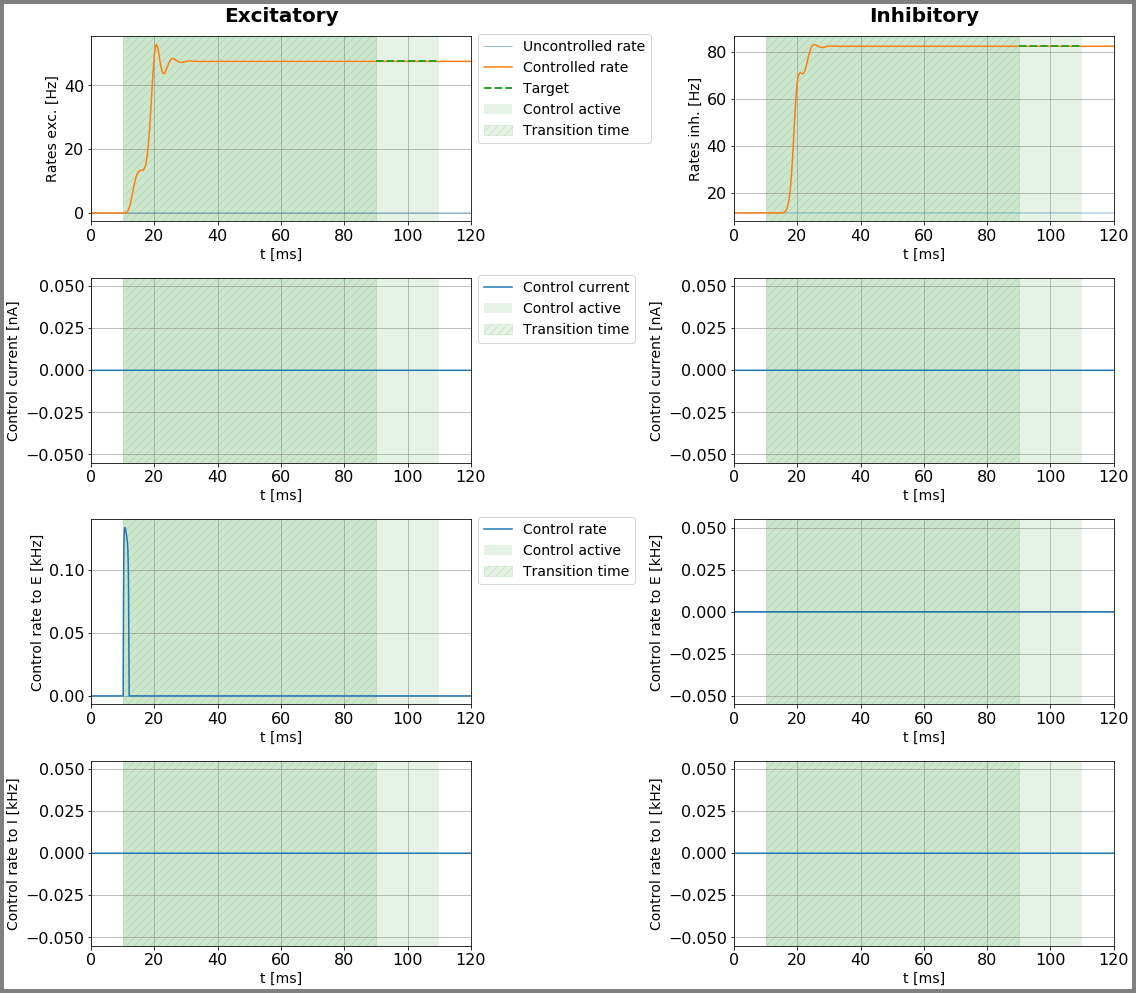

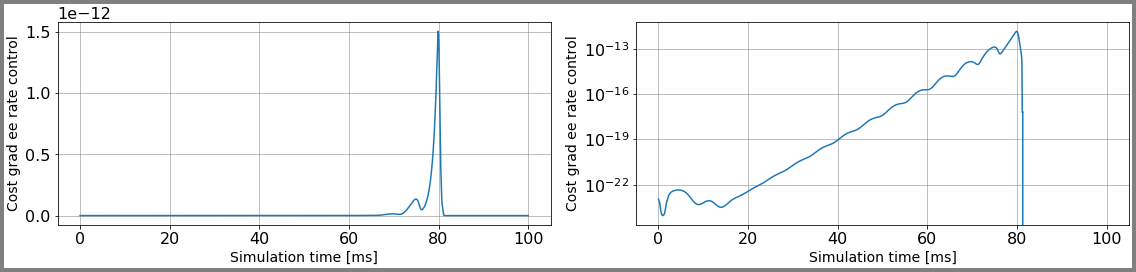

In [11]:
c_ = 3
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  49.601356961063146
RUN  2 , total integrated cost =  37.758138116504256
RUN  3 , total integrated cost =  1.8671983716225413
RUN  4 , total integrated cost =  0.6868458286650921
RUN  5 , total integrated cost =  0.6454158234593481
RUN  6 , total integrated cost =  0.6446797372424953
RUN  7 , total integrated cost =  0.6441392596209556
RUN  8 , total integrated cost =  0.643617523227538
RUN  9 , total integrated cost =  0.6432306679669679
RUN  10 , total integrated cost =  0.6427053233949062
RUN  11 , total integrated cost =  0.6422914213296899
RUN  12 , total integrated cost =  0.6418783788319226
RUN  13 , total integrated cost =  0.6415287608192088
RUN  14 , total integrated cost =  0.6409543772307169
RUN  15 , total integrated cost =  0.6405344866051302
RUN  16 , total 

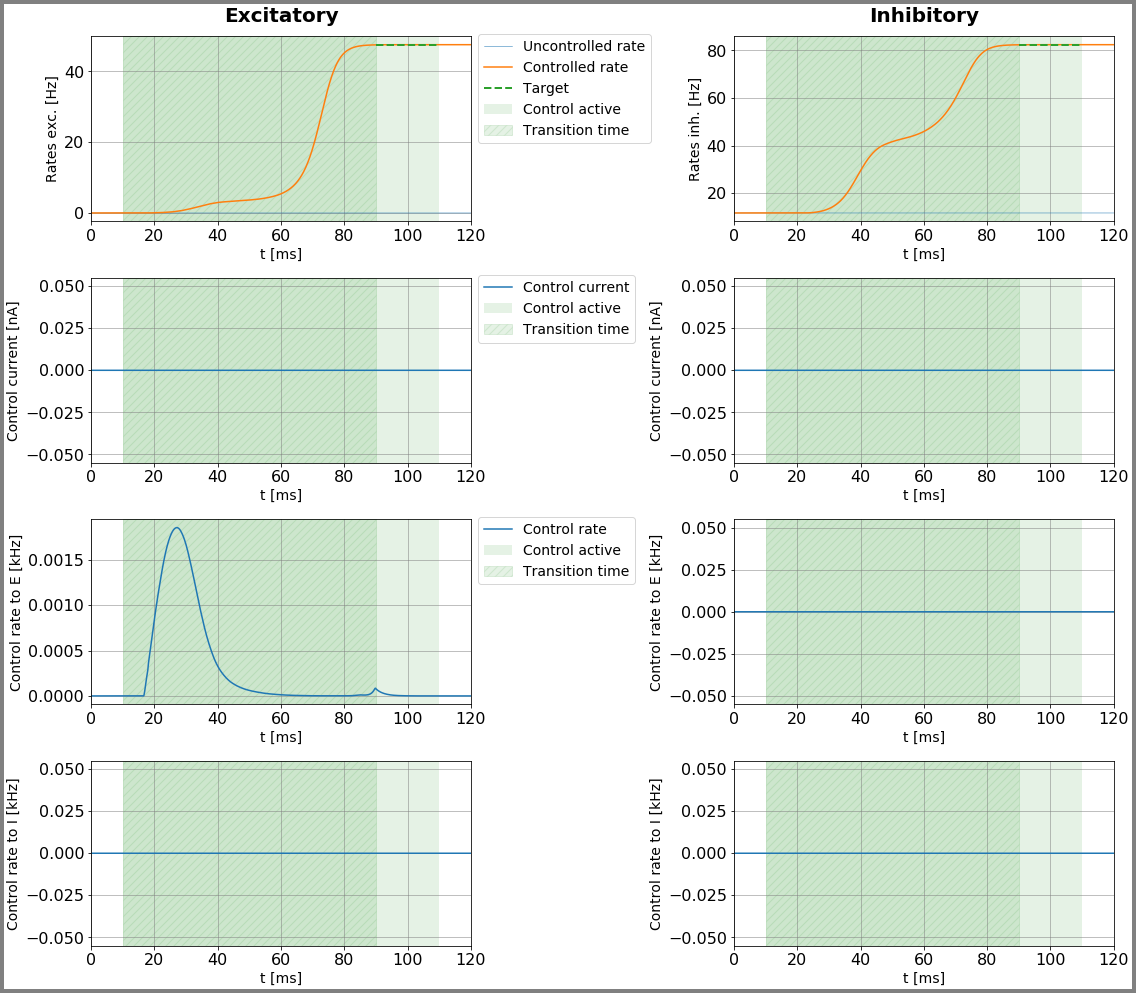

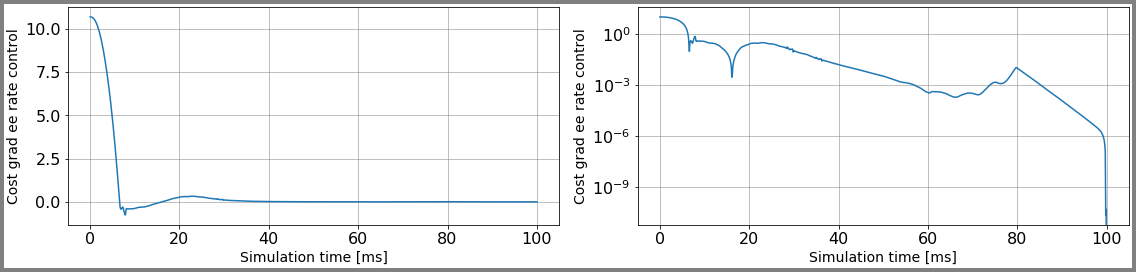

In [12]:
c_ = 3
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 5

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None
RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  0.02306029999999737  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 0.502315898407202 0.5106725653920579
Problem in initial value trasfer:  Vmean_exc -75.52980255335262 -75.53127260362994
Problem in initial value trasfer:  tau_exc 26.65589339209629 26.61416822400367


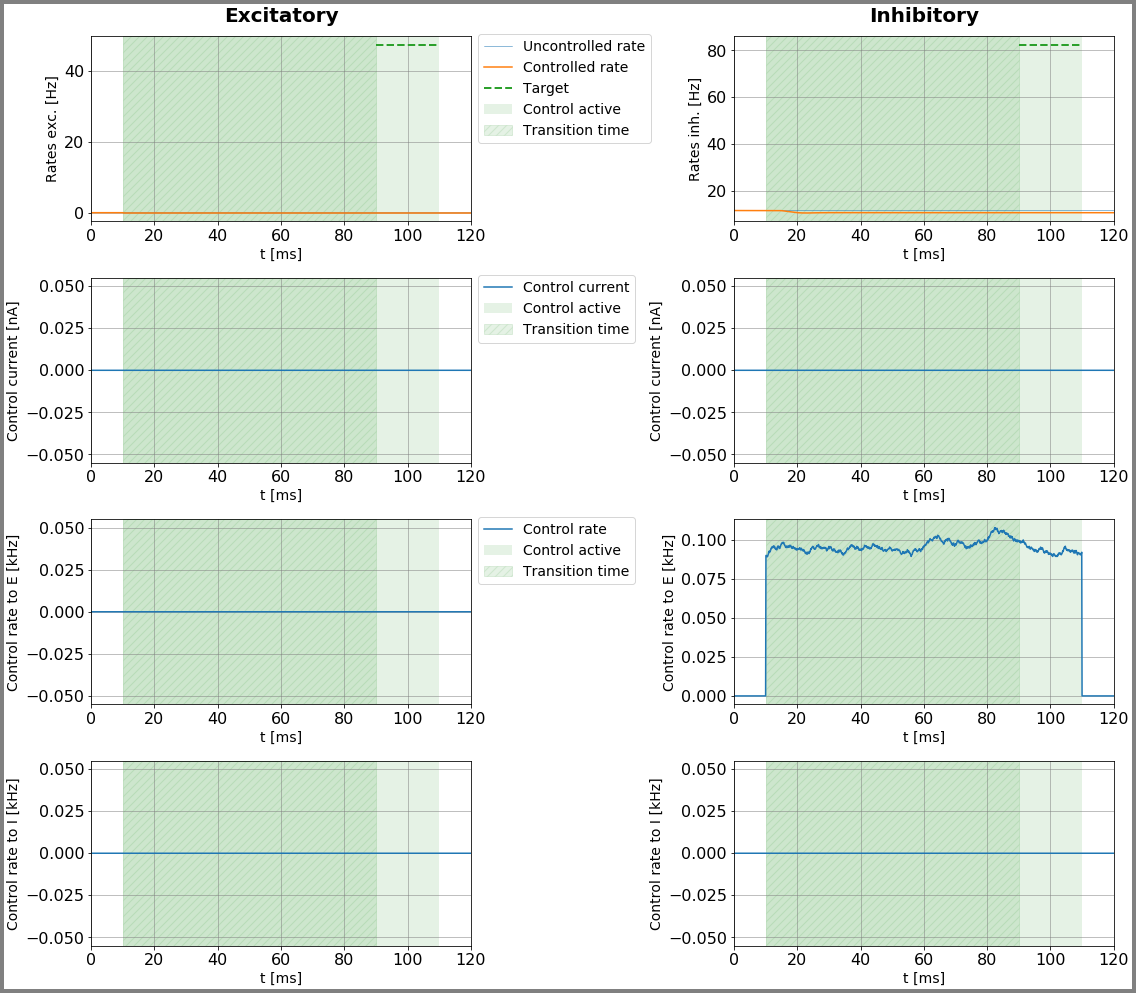

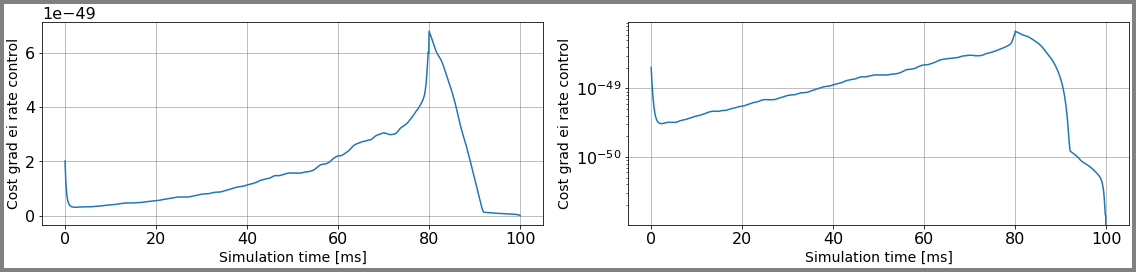

In [13]:
c_ = 4
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.34777445878
RUN  2 , total integrated cost =  22492.302010986437
RUN  3 , total integrated cost =  22492.291594605787
RUN  4 , total integrated cost =  22492.291266410546
RUN  5 , total integrated cost =  22492.291263363306


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  22492.291263363302
RUN  7 , total integrated cost =  22492.291263363302
Control only changes marginally.
RUN  7 , total integrated cost =  22492.291263363302
Improved over  7  iterations in  0.2685645999999906  seconds by  0.0053486498198083154  percent.
Problem in initial value trasfer:  Vmean_exc -56.29876665805448 -56.298893356885614


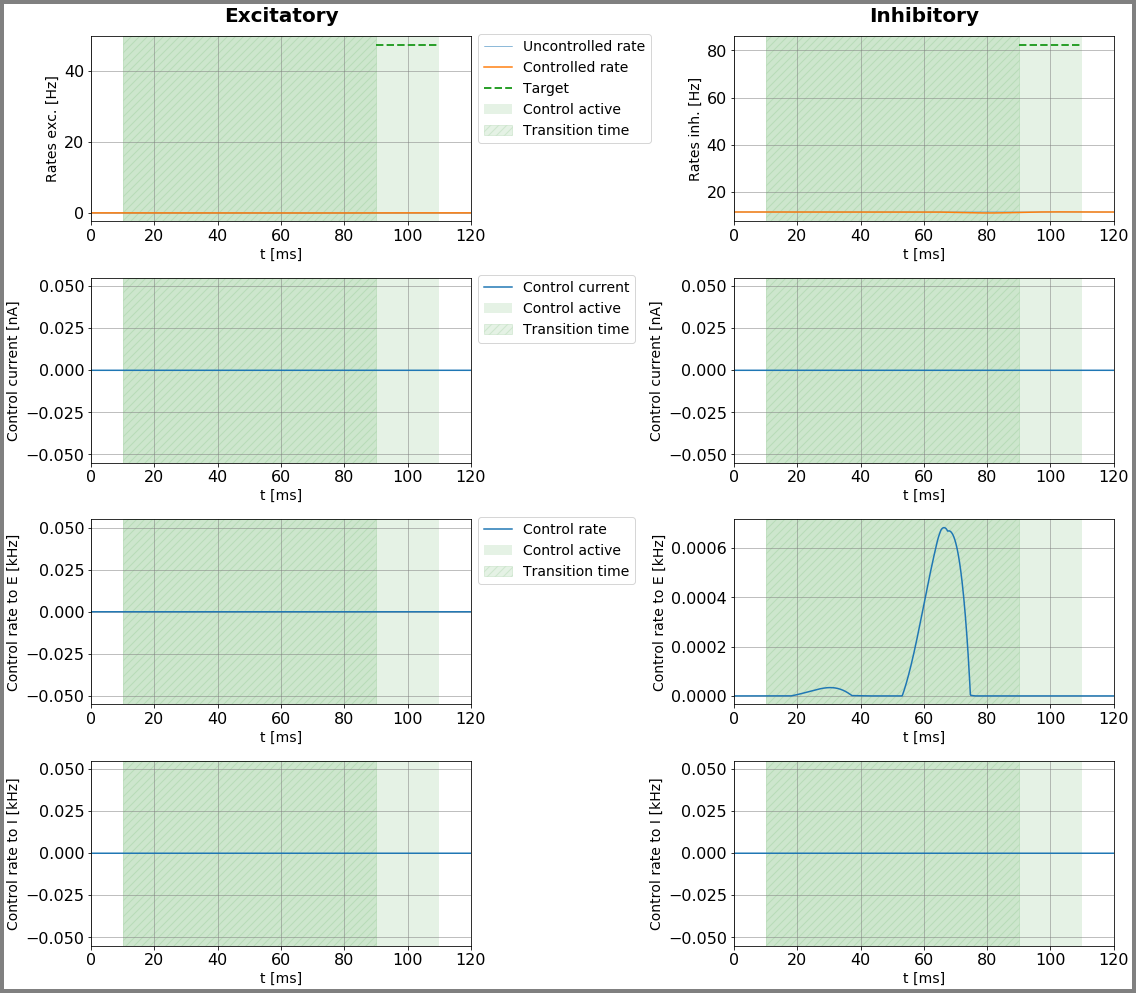

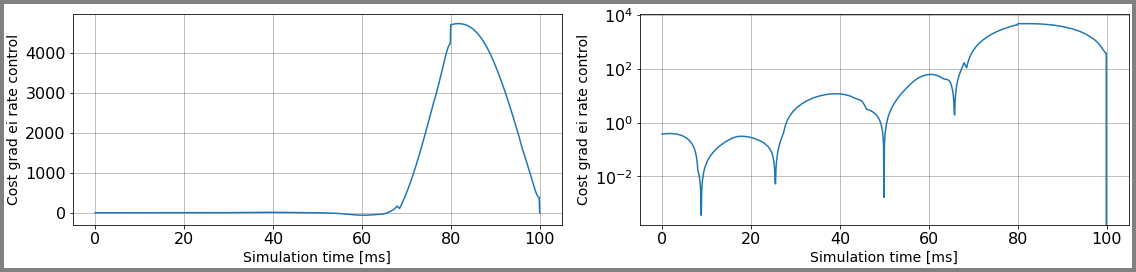

In [14]:
c_ = 4
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 6

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None
RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  0.01671950000002198  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmai_f 0.5054056556346218 0.5300854083324997
Problem in initial value trasfer:  Vmean_exc -75.2143875020316 -75.21680604634273


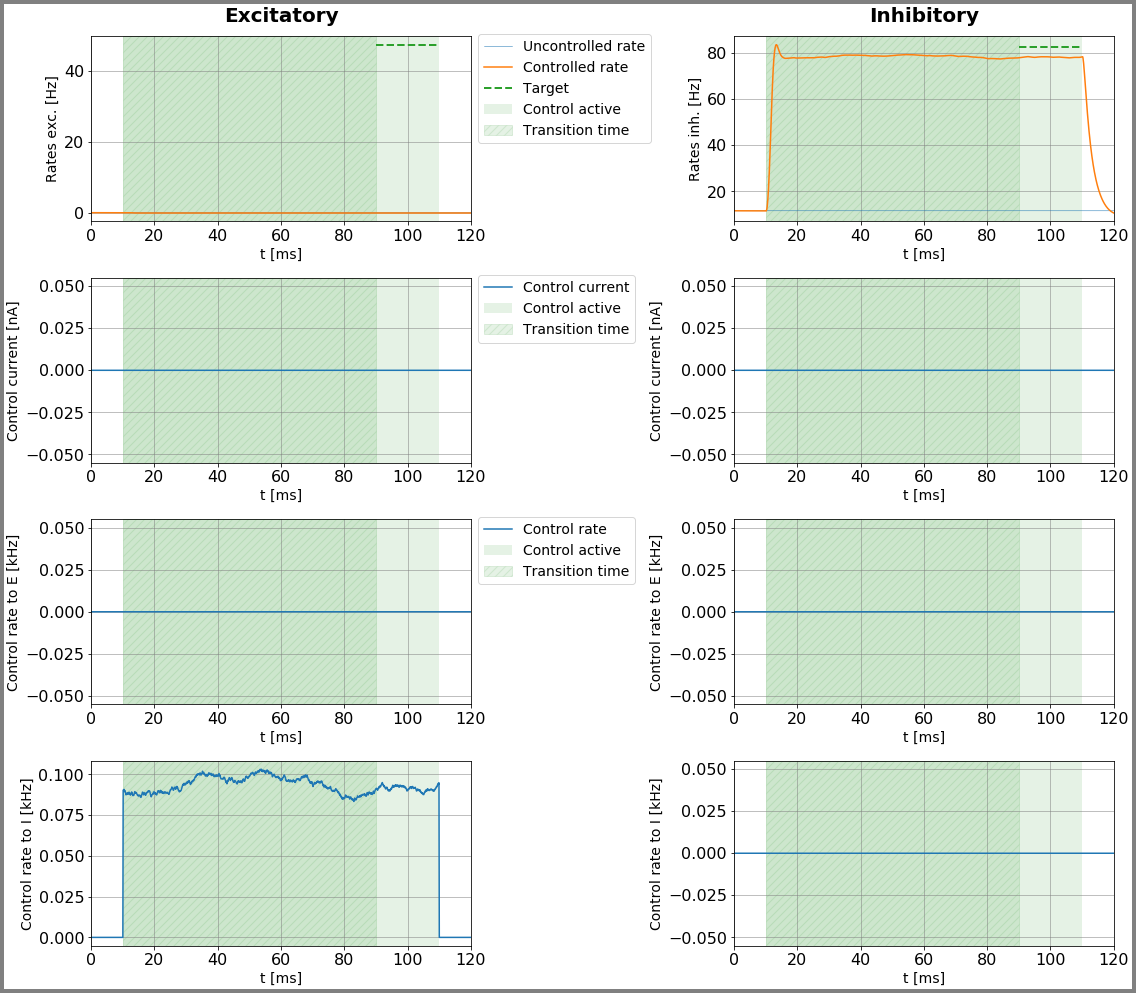

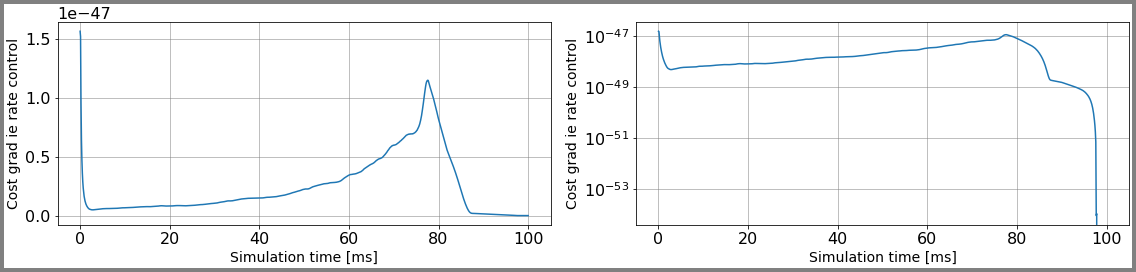

In [15]:
c_ = 5
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.205225769263
RUN  2 , total integrated cost =  22492.184065981408
RUN  3 , total integrated cost =  22492.177371560465
RUN  4 , total integrated cost =  22492.17672661437
RUN  5 , total integrated cost =  22492.176719237006


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  22492.176719139563
RUN  7 , total integrated cost =  22492.176719139563
Control only changes marginally.
RUN  7 , total integrated cost =  22492.176719139563
Improved over  7  iterations in  0.2647879000000444  seconds by  0.005857882497934952  percent.
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.382311323526517
Problem in initial value trasfer:  Vmean_exc -56.29824218663594 -56.298369490351355


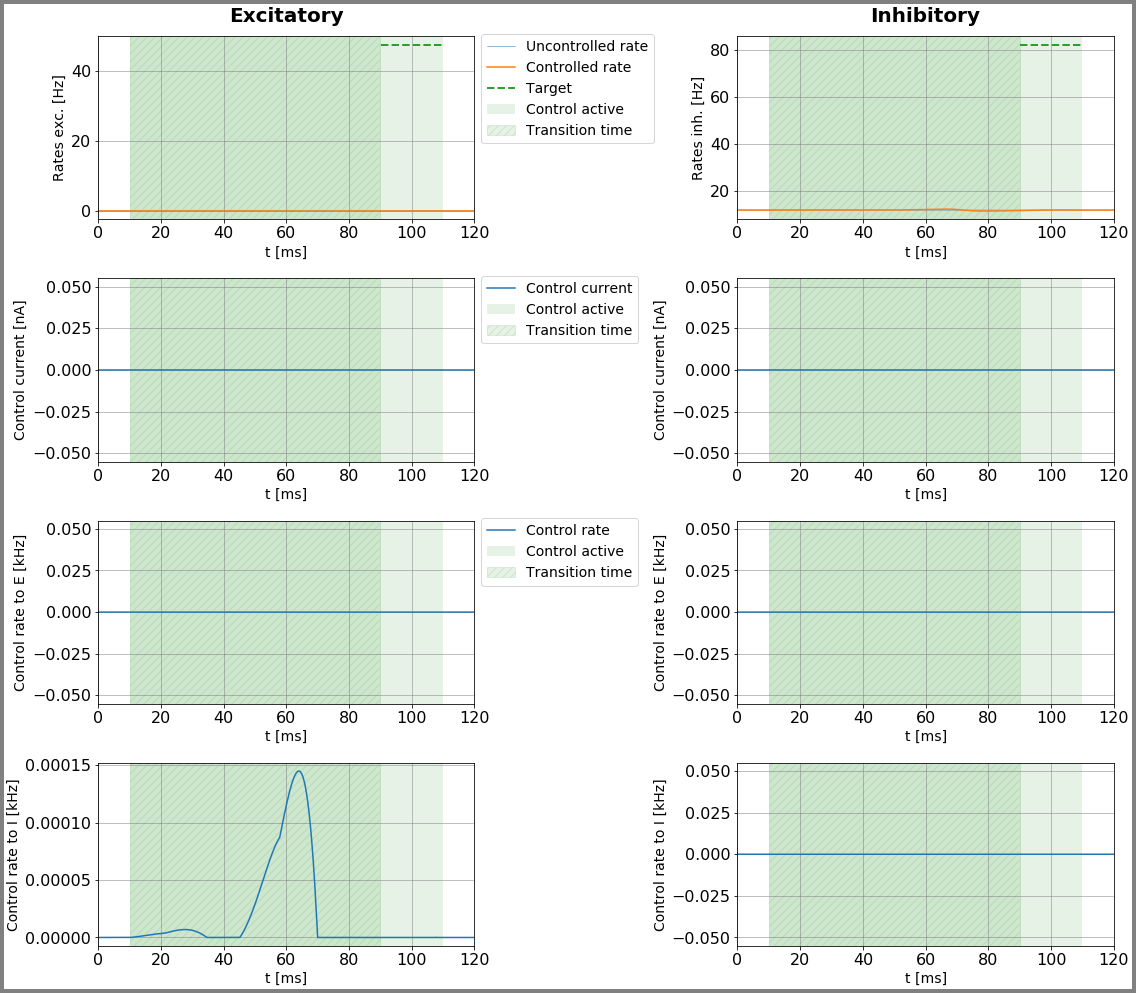

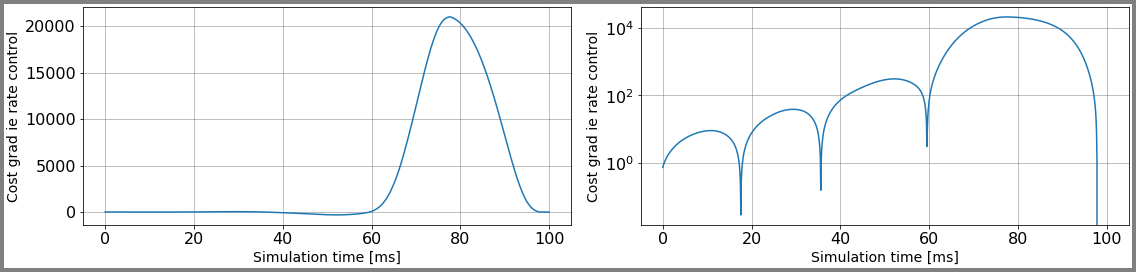

In [16]:
c_ = 5
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 7

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.08278359897462736
Gradient descend method:  None
RUN  1 , total integrated cost =  3.728151704328847e-13
RUN  2 , total integrated cost =  3.117637231736708e-13
RUN  3 , total integrated cost =  2.1408910849297413e-13
RUN  4 , total integrated cost =  1.1464085737628228e-13
RUN  5 , total integrated cost =  3.201271063735759e-14
RUN  6 , total integrated cost =  3.0948374885708866e-14
RUN  7 , total integrated cost =  1.8015851005088135e-14
RUN  8 , total integrated cost =  1.8001547994495295e-14
RUN  9 , total integrated cost =  1.7710087742063765e-14
RUN  10 , total integrated cost =  1.7705157926330942e-14
RUN  11 , total integrated cost =  1.743652272231621e-14
RUN  12 , total integrated cost =  1.7426915208746872e-14
RUN  13 , total integrated cost =  1.7174903510100608e-14
RUN  14 , total integrated cost =  1.717130406425135e-14
RUN  15 , total i

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  283 , total integrated cost =  1.2185317532792055e-14
Improved over  283  iterations in  7.376732699999991  seconds by  99.99999999998528  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5236309419822106
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.489136801837844
Problem in initial value trasfer:  sigmai_f 0.50159800755166 0.50162602400861
Problem in initial value trasfer:  Vmean_exc -56.1745953402893 -56.174606288283066
Problem in initial value trasfer:  tau_inh 0.5110771305764737 0.5110784828388415


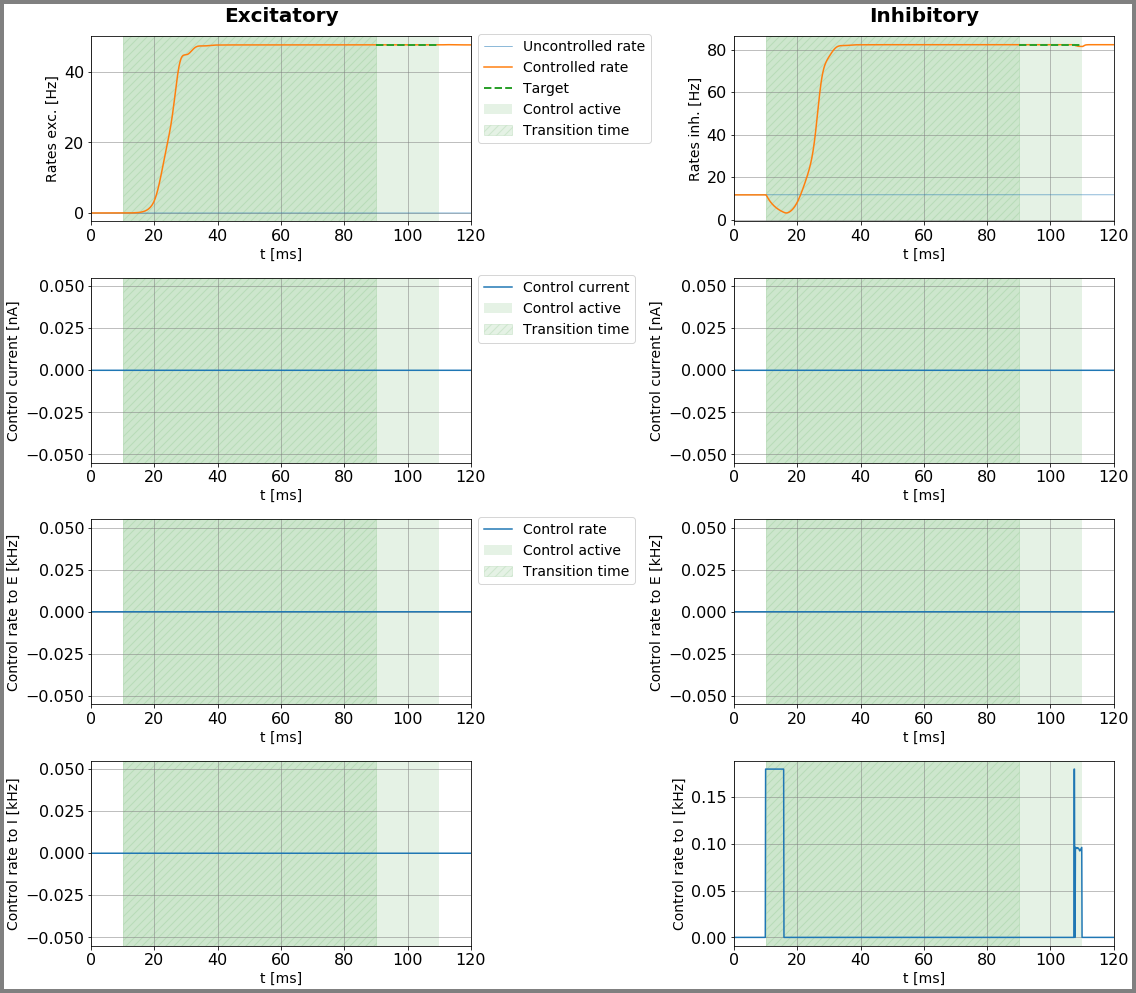

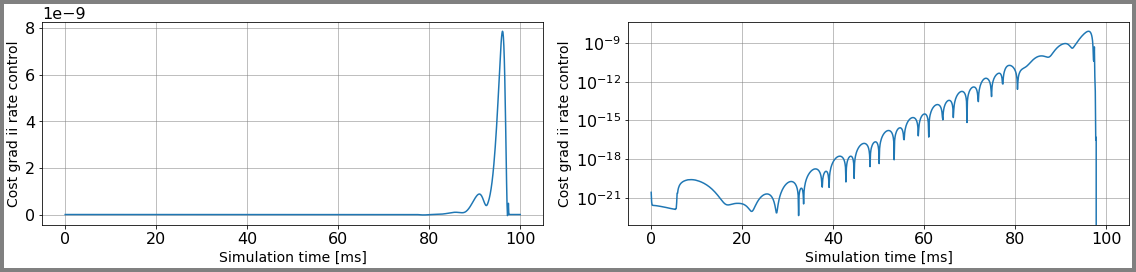

In [17]:
c_ = 6
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  92.99442100276349
RUN  2 , total integrated cost =  88.7472736972424
RUN  3 , total integrated cost =  6.9860589470695675
RUN  4 , total integrated cost =  3.7991385523139773
RUN  5 , total integrated cost =  2.7485993879929556
RUN  6 , total integrated cost =  2.731937810177385
RUN  7 , total integrated cost =  2.720387129699815
RUN  8 , total integrated cost =  2.7013523896579077
RUN  9 , total integrated cost =  2.6896371202005143
RUN  10 , total integrated cost =  2.671477699226443
RUN  11 , total integrated cost =  2.663155253775059
RUN  12 , total integrated cost =  2.652040895153499
RUN  13 , total integrated cost =  2.6452471669230797
RUN  14 , total integrated cost =  2.63597320070165
RUN  15 , total integrated cost =  2.6302381348709187
RUN  16 , total integrate

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  2.3999894527983914
RUN  1000 , total integrated cost =  2.3999894527983914
Improved over  1000  iterations in  23.79276520000002  seconds by  99.98933029517684  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459052820805 -56.174590557330674


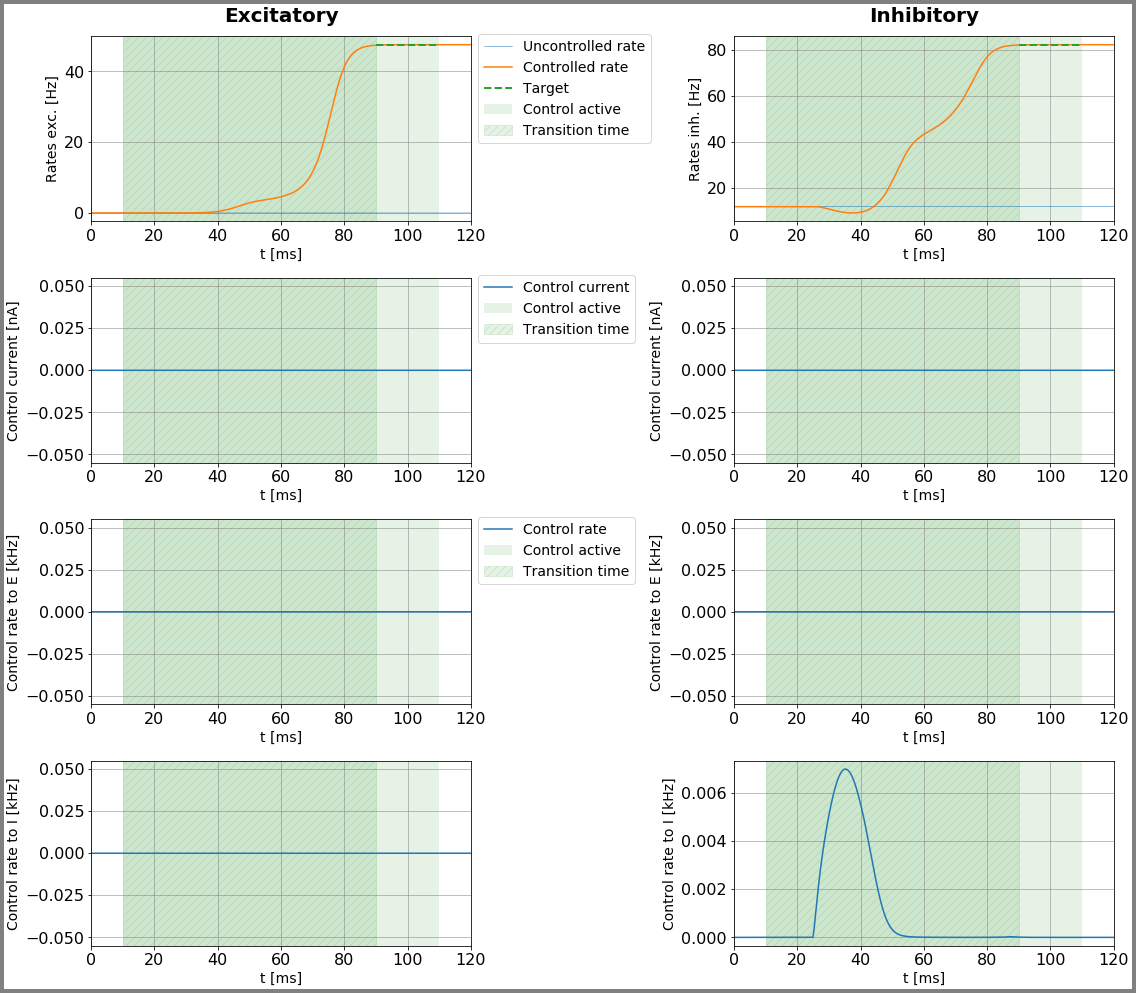

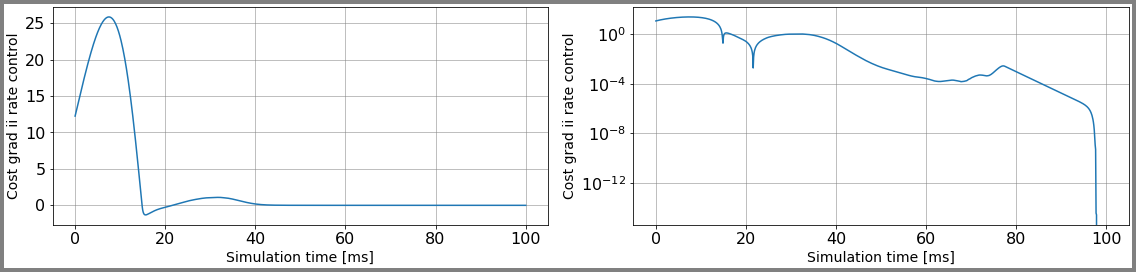

In [18]:
c_ = 6
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 8

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12.913401688179787
Gradient descend method:  None
RUN  1 , total integrated cost =  0.11275827402541666
RUN  2 , total integrated cost =  0.015094442514200479
RUN  3 , total integrated cost =  0.006210980236211681
RUN  4 , total integrated cost =  0.0035697684788340246
RUN  5 , total integrated cost =  0.002386537523676058
RUN  6 , total integrated cost =  0.0017336913047943771
RUN  7 , total integrated cost =  0.0013343435430551746
RUN  8 , total integrated cost =  0.0010649663635046418
RUN  9 , total integrated cost =  0.0008741780359492123
RUN  10 , total integrated cost =  0.0007329335731217126
RUN  11 , total integrated cost =  0.0006251540555057204
RUN  12 , total integrated cost =  0.0005395535335775217
RUN  13 , total integrated cost =  0.0004697818660463251
RUN  14 , total integrated cost =  0.00041455680819476345
RUN  15 , total integr

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  4.489622339591983e-10
RUN  1000 , total integrated cost =  4.489622339591983e-10
Improved over  1000  iterations in  48.77939550000002  seconds by  99.99999999652329  percent.
Problem in initial value trasfer:  sigmae_f 0.5009419058412012 0.5015023695333682
Problem in initial value trasfer:  sigmai_f 0.5004924809113673 0.5007586624922115
Problem in initial value trasfer:  Vmean_exc -56.17359597932401 -56.172770980097965


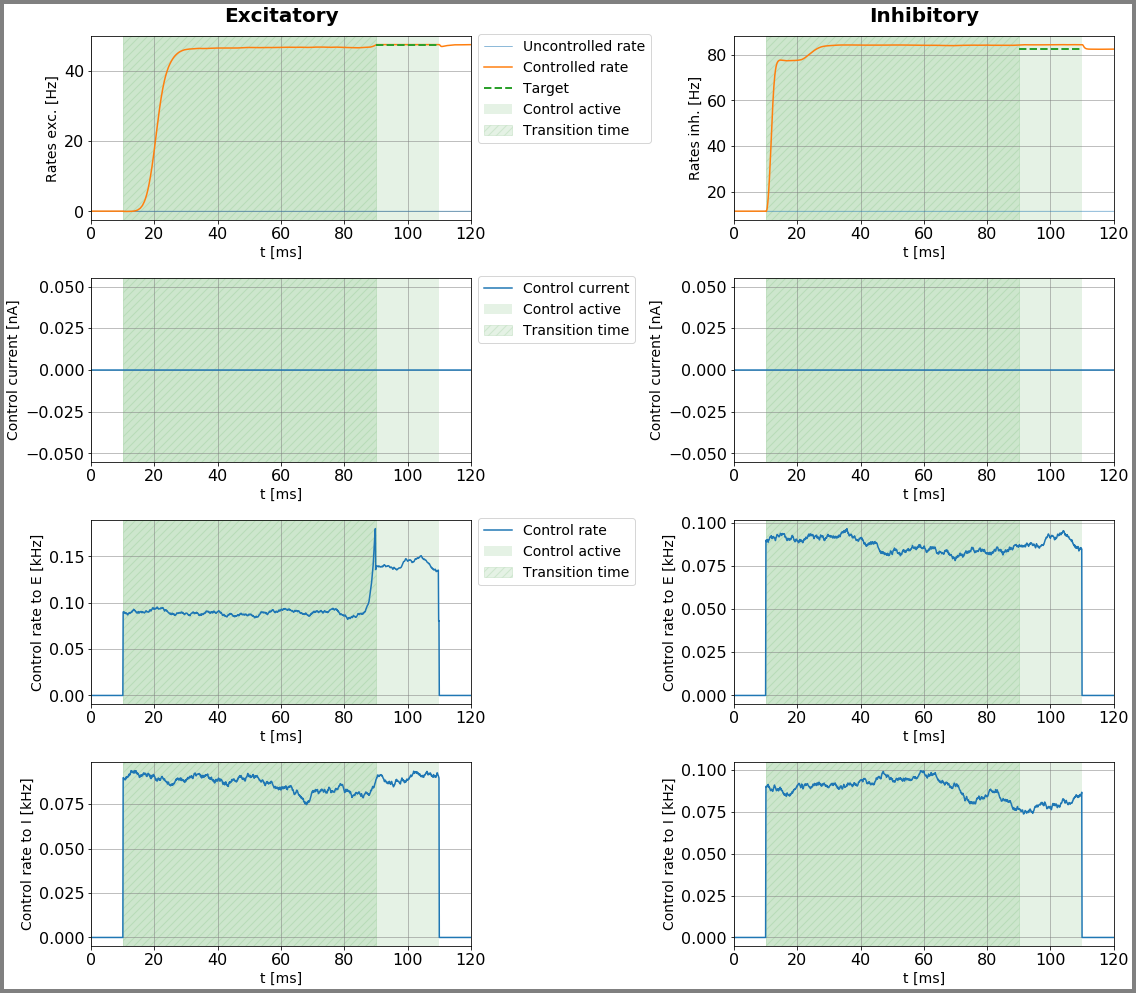

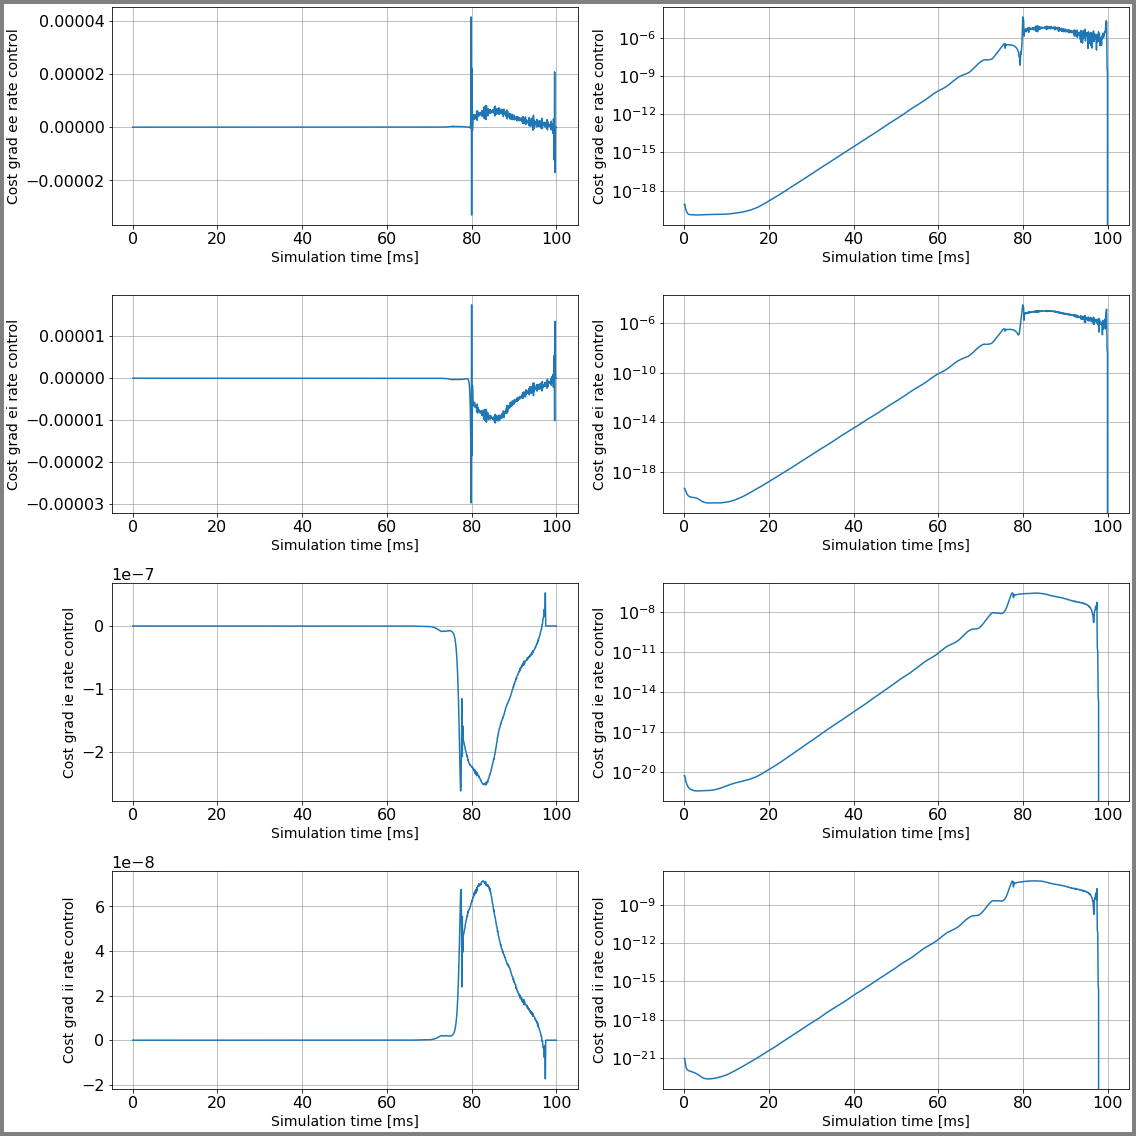

In [19]:
c_ = 7
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  49.601356961063146
RUN  2 , total integrated cost =  37.758138116504256
RUN  3 , total integrated cost =  1.8671983716225413
RUN  4 , total integrated cost =  0.6868458286650921
RUN  5 , total integrated cost =  0.6454158234593481
RUN  6 , total integrated cost =  0.6446797372424953
RUN  7 , total integrated cost =  0.6441392596209556
RUN  8 , total integrated cost =  0.643617523227538
RUN  9 , total integrated cost =  0.6432306679669679
RUN  10 , total integrated cost =  0.6427053233949062
RUN  11 , total integrated cost =  0.6422914213296899
RUN  12 , total integrated cost =  0.6418783788319226
RUN  13 , total integrated cost =  0.6415287608192088
RUN  14 , total integrated cost =  0.6409543772307169
RUN  15 , total integrated cost =  0.6405344866051302
RUN  16

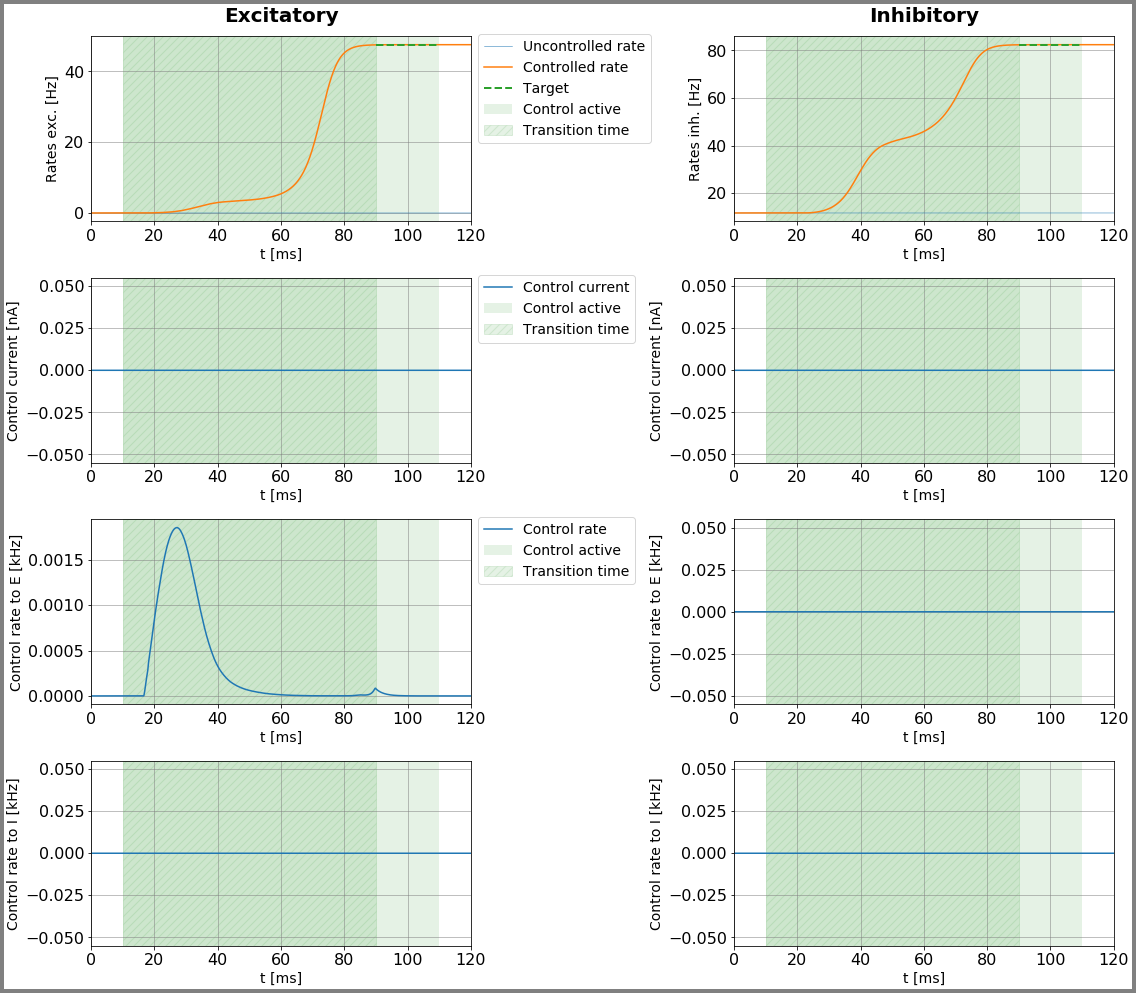

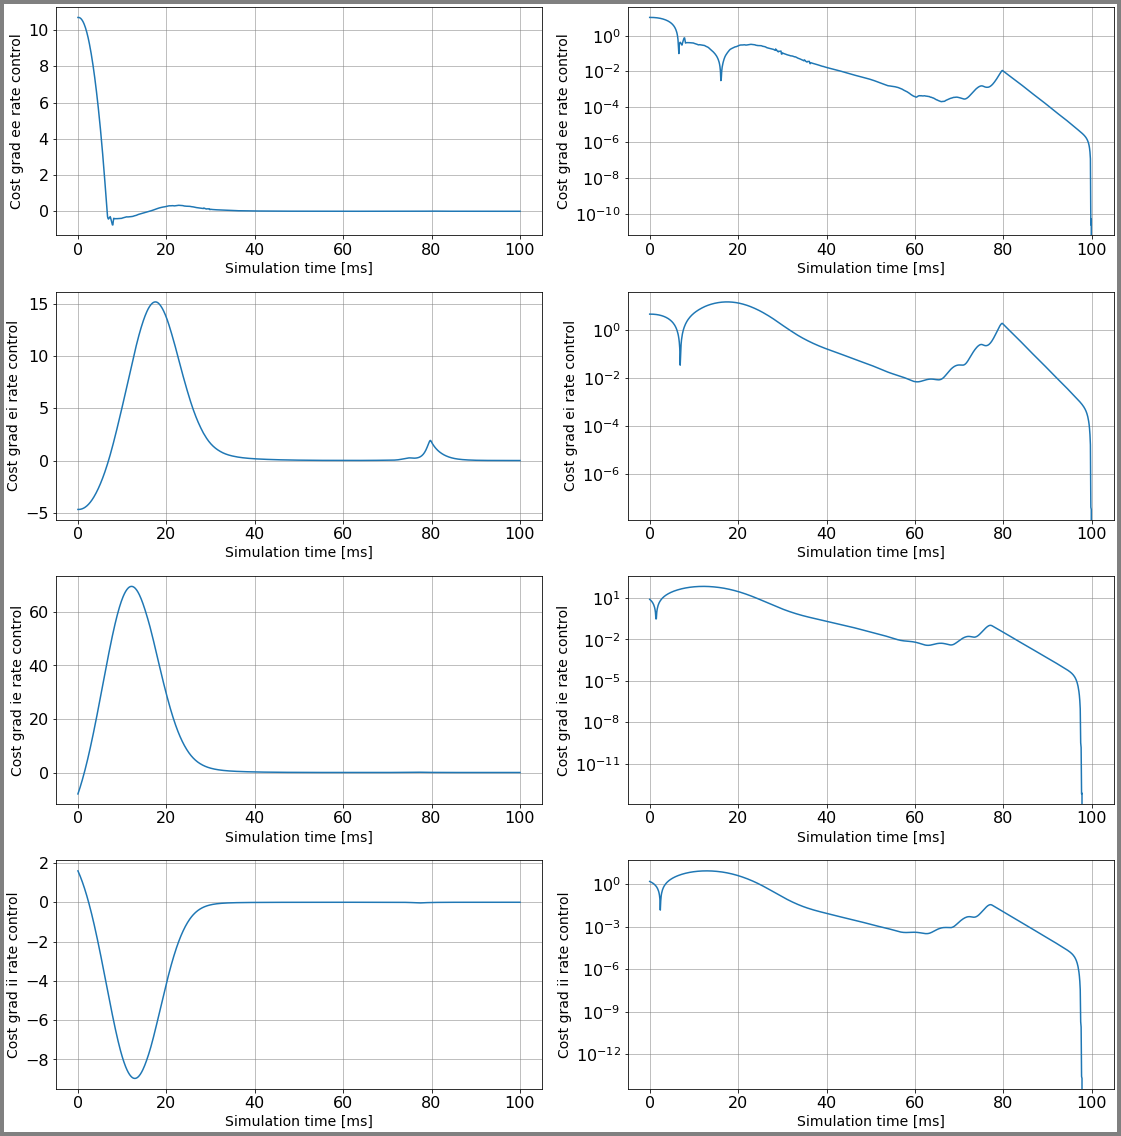

In [20]:
c_ = 7
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [21]:
print("cost a")
for i in range(len(costa)):
    j = int(len(costa[i]) - 1)
    while costa[i][j] == 0.:
        j = int(j-1)
    print(costa[i][j])

print("cost b")
for i in range(len(costb)):
    j = int(len(costb[i]) - 1)
    while costb[i][j] == 0.:
        j = int(j-1)
    print(costb[i][j])

cost a
7.879666414572664e-08
8.326046583743515e-08
0.00046238711798886074
1.5045155184375141e-27
22571.787712787307
22571.787712787307
1.2185317532792055e-14
4.489622339591983e-10
cost b
102.18155693670033
49.56715340042566
49.73410507097368
0.6144465458178285
22492.291263363302
22492.176719139563
2.3999894527983914
0.6144465458178285
